# Day 4 — Feature Importance & Model Tuning

## Objective
Identify which features most strongly influence dose predictions and improve model performance
while maintaining clinical interpretability.

## Deliverables
- Feature importance from:
  - Linear Regression (directional coefficients)
  - Random Forest (non-linear importance)
- Tuned Random Forest using controlled hyperparameter search
- Comparison of baseline vs tuned performance (MAE, RMSE, R²)

In [5]:
import pandas as pd
import numpy as np

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [6]:
# Load prepared dataset
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "curated" / "merged_patient_dataset_prepared.csv"

df = pd.read_csv(DATA_PATH)

TARGET = "Final_Stable_Dose_mg"

X = df.drop(columns=[TARGET, "patient_id", "Adverse_Event"])
y = df[TARGET]

In [7]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# ----------------------------
# Sanity check: confirm required objects exist
# ----------------------------
required = ["X_train", "X_test", "y_train", "y_test", "preprocessor", "numeric_features", "categorical_features"]
missing = [name for name in required if name not in globals()]

if missing:
    print("❌ Missing objects:", missing)
else:
    print("✅ All required objects are available. Ready for Day 4.")

✅ All required objects are available. Ready for Day 4.


In [9]:
# ----------------------------
# Linear Regression: interpretable baseline
# Coefficients tell direction:
#   +ve => increases predicted dose
#   -ve => decreases predicted dose
# ----------------------------
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearRegression())
    ]
)

lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age', 'Weight_kg',
                                                   'Height_cm', 'Hypertension',
                                                   'Diabetes',
                                                   'Chronic_Kidney_Disease',
                                                   'Heart_Failure',
                                                   'Amiodarone', 'Antibiotics',
                                                   'Aspirin', 'Statins',
                                                   'INR_Stabilization_Days',
                                                   'Time_in_Therapeutic_Range_Pct',
                                                   'Adverse_Event_Flag']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['CYP2C9', 'VKORC1', 'CYP4F2',
                                                   'Sex', 'Ethnicity',
                                                   'Alcohol_Intake',
                                                   'Smoking_Status',
                                                   'Diet_VitK_Intake'])])),
                ('model', LinearRegression())])

In [10]:
# ----------------------------
# Extract feature names after one-hot encoding so coefficients are readable
# ----------------------------
encoded_cat_features = (
    lr_model.named_steps["preprocess"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

feature_names = numeric_features + list(encoded_cat_features)

coefficients = lr_model.named_steps["model"].coef_

lr_importance = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
)

# Top 20 most influential coefficients
lr_importance.head(20)

,feature,coefficient,abs_coef
26,Sex_F,1.385342e+10,1.385342e+10
27,Sex_M,1.385342e+10,1.385342e+10
29,Ethnicity_Asian,-1.376674e+10,1.376674e+10
31,Ethnicity_Hispanic,-1.376674e+10,1.376674e+10
30,Ethnicity_Caucasian,-1.376674e+10,1.376674e+10
32,Ethnicity_Other,-1.376674e+10,1.376674e+10
28,Ethnicity_African American,-1.376674e+10,1.376674e+10
38,Smoking_Status_Non-smoker,-7.820663e+09,7.820663e+09
39,Smoking_Status_Smoker,-7.820663e+09,7.820663e+09
37,Smoking_Status_Former Smoker,-7.820663e+09,7.820663e+09


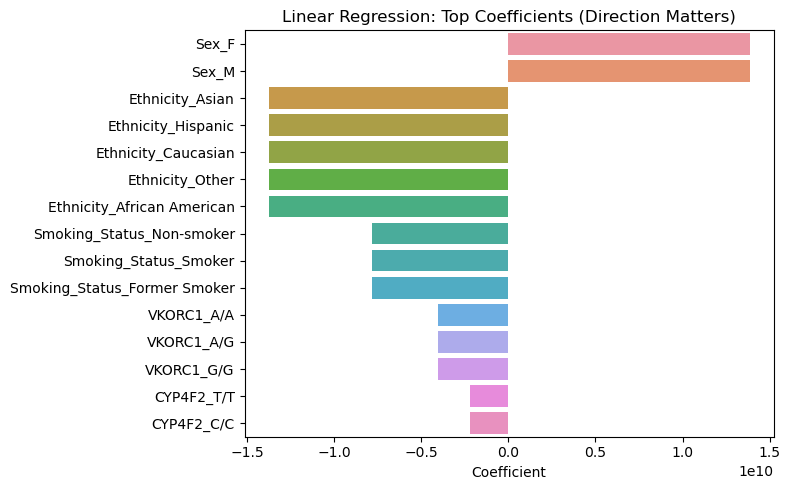

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

top_lr = lr_importance.head(15).copy()

plt.figure(figsize=(8, 5))
sns.barplot(data=top_lr, x="coefficient", y="feature")
plt.title("Linear Regression: Top Coefficients (Direction Matters)")
plt.xlabel("Coefficient")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [12]:
# ----------------------------
# Random Forest: captures non-linear effects + interactions
# Feature importance shows contribution, not direction
# ----------------------------
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age', 'Weight_kg',
                                                   'Height_cm', 'Hypertension',
                                                   'Diabetes',
                                                   'Chronic_Kidney_Disease',
                                                   'Heart_Failure',
                                                   'Amiodarone', 'Antibiotics',
                                                   'Aspirin', 'Statins',
                                                   'INR_Stabilization_Days',
                                                   'Time_in_Therapeutic_Range_Pct',
                                                   'Adverse_Event_Flag']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['CYP2C9', 'VKORC1', 'CYP4F2',
                                                   'Sex', 'Ethnicity',
                                                   'Alcohol_Intake',
                                                   'Smoking_Status',
                                                   'Diet_VitK_Intake'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [13]:
# ----------------------------
# Extract Random Forest feature importances
# ----------------------------
rf_importances = rf_model.named_steps["model"].feature_importances_

rf_importance = (
    pd.DataFrame({"feature": feature_names, "importance": rf_importances})
    .sort_values("importance", ascending=False)
)

rf_importance.head(20)

,feature,importance
14,CYP2C9_*1/*1,0.356824
22,VKORC1_G/G,0.333077
15,CYP2C9_*1/*2,0.055567
7,Amiodarone,0.040736
0,Age,0.024252
12,Time_in_Therapeutic_Range_Pct,0.024142
28,Ethnicity_African American,0.022413
1,Weight_kg,0.020854
20,VKORC1_A/A,0.014498
21,VKORC1_A/G,0.014377


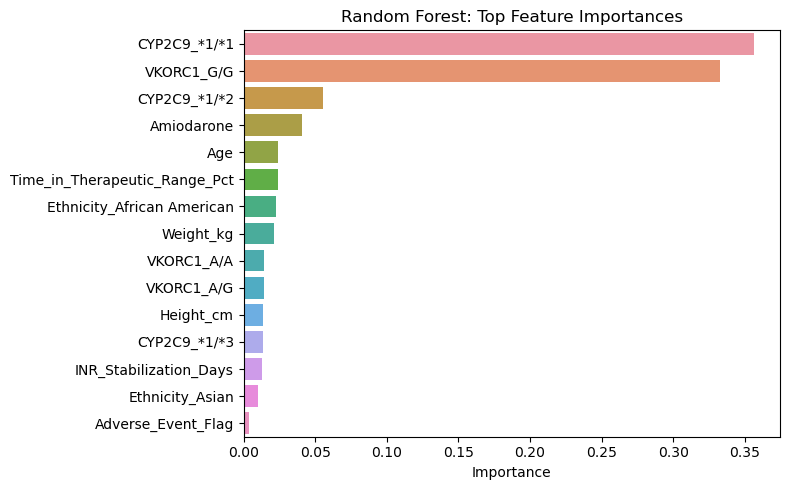

In [14]:
top_rf = rf_importance.head(15).copy()

plt.figure(figsize=(8, 5))
sns.barplot(data=top_rf, x="importance", y="feature")
plt.title("Random Forest: Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Feature Importance Interpretation

Linear Regression coefficients show strong directional effects for genetic variants,
with VKORC1 and CYP4F2 associated with reduced dose requirements and smoking status
and sex contributing positively to dose adjustments.

Random Forest feature importance confirms that genetic features (CYP2C9 and VKORC1)
are the dominant predictors of dose, accounting for the majority of explained variance.
Clinical variables such as age, body size, and amiodarone use provide secondary but
meaningful contributions, while lifestyle and demographic features act as modifiers.

Overall, the results align closely with established pharmacogenetic knowledge and
support the clinical validity of the modelling approach.

# PART B — Model Tuning (Controlled Grid Search)

In [15]:
# ----------------------------
# Controlled tuning grid
# - Keeps search small (fast + defensible)
# - Uses MAE as objective (clinically intuitive)
# ----------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

param_grid = {
    "model__n_estimators": [300],
    "model__max_depth": [None, 15, 25],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 5]
}

rf_tuned = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

grid = GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

grid.best_params_


Fitting 3 folds for each of 12 candidates, totalling 36 fits


{'model__max_depth': 15,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 10,
 'model__n_estimators': 300}

In [16]:
# ----------------------------
# Evaluate the tuned model on the held-out test set
# ----------------------------
best_rf = grid.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

rf_tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
rf_tuned_rmse = mean_squared_error(y_test, y_pred_tuned, squared=False)
rf_tuned_r2 = r2_score(y_test, y_pred_tuned)

rf_tuned_mae, rf_tuned_rmse, rf_tuned_r2

(0.40072372941003853, 0.5570695416937564, 0.8819100422043928)

In [17]:
# ----------------------------
# If you already have baseline engineered RF metrics (rf_fe_mae etc.), use them here.
# If not, compute baseline RF metrics quickly from rf_model (trained above).
# ----------------------------

# Baseline RF predictions from rf_model (already fitted above)
y_pred_rf_base = rf_model.predict(X_test)

rf_base_mae = mean_absolute_error(y_test, y_pred_rf_base)
rf_base_rmse = mean_squared_error(y_test, y_pred_rf_base, squared=False)
rf_base_r2 = r2_score(y_test, y_pred_rf_base)

pd.DataFrame({
    "Model": ["Random Forest (Baseline)", "Random Forest (Tuned)"],
    "MAE": [rf_base_mae, rf_tuned_mae],
    "RMSE": [rf_base_rmse, rf_tuned_rmse],
    "R2": [rf_base_r2, rf_tuned_r2]
})

,Model,MAE,RMSE,R2
0,Random Forest (Baseline),0.404405,0.563303,0.879253
1,Random Forest (Tuned),0.400724,0.557070,0.881910
